In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import regularizers
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import RobustScaler, LabelEncoder, StandardScaler # Import LabelEncoder and StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
data_train = pd.read_csv("KDDTrain+.txt", header=None)
data_test = pd.read_csv("KDDTest+.txt", header=None)

columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])
data_train.columns = columns

In [3]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])

In [5]:
data_train.columns = columns
data_test.columns = columns

In [6]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
data_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  str    
 2   service                      22544 non-null  str    
 3   flag                         22544 non-null  str    
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell                 

In [8]:
attack_mapping = {
    'normal': 'normal',
    'neptune': 'DoS',
    'smurf': 'DoS',
    'back': 'DoS',
    'teardrop': 'DoS',
    'pod': 'DoS',
    'land': 'DoS',
    'apache2': 'DoS',
    'mailbomb': 'DoS',
    'processtable': 'DoS',
    'udpstorm': 'DoS',
    'nuked': 'DoS',
    'worm': 'DoS',

    'ipsweep': 'Probe',
    'portsweep': 'Probe',
    'nmap': 'Probe',
    'satan': 'Probe',
    'mscan': 'Probe',
    'saint': 'Probe',
    'xsnoop': 'Probe',
    'snmpgetattack': 'Probe',
    'snmpguess': 'Probe',
    'httptunnel': 'Probe',

    'warezclient': 'R2L',
    'guess_passwd': 'R2L',
    'ftp_write': 'R2L',
    'multihop': 'R2L',
    'imap': 'R2L',
    'warezmaster': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'sendmail': 'R2L',
    'secrect': 'R2L',

    'rootkit': 'U2R',
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'ps': 'U2R',
    'sqlattack': 'U2R',
    'xterm': 'U2R',
    'named': 'U2R',
    'xlock': 'U2R'
}

unmapped_attacks = set(data_train['outcome'].unique()) - set(attack_mapping.keys())
if unmapped_attacks:
    print(f"Warning: The following attack types in 'outcome' are not in the provided mapping: {unmapped_attacks}. They will be mapped to 'Other_Attack'.")
    for attack in unmapped_attacks:
        attack_mapping[attack] = 'Other_Attack'

data_train['attack_class'] = data_train['outcome'].map(attack_mapping)
data_test['attack_class'] = data_test['outcome'].map(attack_mapping)

print("\nValue counts for 'attack_class' after mapping:")
print(data_train['attack_class'].value_counts())
print("\nValue counts for 'attack_class' in test set after mapping:")
print(data_test['attack_class'].value_counts())


Value counts for 'attack_class' after mapping:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Value counts for 'attack_class' in test set after mapping:
attack_class
normal    9711
DoS       7460
Probe     3067
R2L       2213
U2R         93
Name: count, dtype: int64


In [9]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [10]:
data_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.0,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,0.001342,0.001103,0.302192,0.012669,0.000413,0.004096,0.0,0.000008,0.009423,84.107555,27.737888,0.284485,0.282485,0.119958,0.121183,0.660928,0.063053,0.097322,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,0.036603,0.045154,24.399618,0.483935,0.022181,0.099370,0.0,0.002817,0.096612,114.508607,72.635840,0.446456,0.447022,0.320436,0.323647,0.439623,0.180314,0.259830,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.0,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [11]:
def pie_plot(df, cols_list, rows, cols):
    fig, axes = plt.subplots(rows, cols)
    for ax, col in zip(axes.ravel(), cols_list):
        df[col].value_counts().plot(ax=ax, kind='pie', figsize=(15, 15), fontsize=10, autopct='%1.0f%%')
        ax.set_title(str(col), fontsize = 12)
    plt.show()

In [14]:
# print("Unique values for 'num_outbound_cmds':", data_train['num_outbound_cmds'].unique())
# print("Unique values for 'land':", data_train['land'].unique())
# print("Unique values for 'urgent':", data_train['urgent'].unique())

# data_train_cleaned = data_train.drop(columns=['num_outbound_cmds', 'land', 'urgent','level'])
# data_test_cleaned = data_test.drop(columns=['num_outbound_cmds', 'land', 'urgent','level'])

# print(f"Original number of columns: {data_train.shape[1]}")
# print(f"Number of columns after dropping irrelevant features: {data_train_cleaned.shape[1]}")
# print(f"Original number of columns in test set: {data_test.shape[1]}")
# print(f"Number of columns in test set after dropping irrelevant features: {data_test_cleaned.shape[1]}")

In [15]:
# corr_matrix = data_train_cleaned.corr(numeric_only=True).abs()
# upper = corr_matrix.where(
#     np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
# )
# to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
# print("Highly correlated features:")
# print(to_drop)
# data_train_final = data_train_cleaned.drop(columns=to_drop)
# data_test_final = data_test_cleaned.drop(columns=to_drop)
# data_train_final.drop(columns=['outcome'], inplace=True)
# data_test_final.drop(columns=['outcome'], inplace=True)

In [12]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [13]:
def Scaling(df_num, cols):
    std_scaler = RobustScaler()
    std_scaler_temp = std_scaler.fit_transform(df_num)
    std_df = pd.DataFrame(std_scaler_temp, columns =cols)
    return std_df

In [14]:
data_train = pd.get_dummies(
    data_train,
    columns=['protocol_type', 'service', 'flag'],
    drop_first=True
)
data_test = pd.get_dummies(
    data_test,
    columns=['protocol_type', 'service', 'flag'],
    drop_first=True
)

In [15]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Columns: 122 entries, duration to flag_SH
dtypes: bool(81), float64(15), int64(24), str(2)
memory usage: 49.1 MB


In [16]:
data_train, data_test = data_train.align(
    data_test,
    join='left',
    axis=1,
    fill_value=0
)

In [17]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Columns: 122 entries, duration to flag_SH
dtypes: bool(81), float64(15), int64(24), str(2)
memory usage: 49.1 MB


In [18]:
data_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Columns: 122 entries, duration to flag_SH
dtypes: bool(75), float64(15), int64(30), str(2)
memory usage: 9.7 MB


In [19]:
data_train['attack_class'].value_counts()

attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

In [20]:
data_train_final=data_train.copy()
data_test_final=data_test.copy()

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data_train_final['attack_class'] = le.fit_transform(data_train_final['attack_class'])
data_test_final['attack_class'] = le.transform(data_test_final['attack_class'])

In [22]:
X_train = data_train_final.drop(['attack_class', 'outcome'], axis=1)
y_train = data_train_final['attack_class']
X_test = data_test_final.drop(['attack_class', 'outcome'], axis=1)
y_test = data_test_final['attack_class']

In [23]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Columns: 120 entries, duration to flag_SH
dtypes: bool(81), float64(15), int64(24)
memory usage: 47.2 MB


In [24]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'DoS': np.int64(0), 'Probe': np.int64(1), 'R2L': np.int64(2), 'U2R': np.int64(3), 'normal': np.int64(4)}


In [25]:
# from imblearn.combine import SMOTEENN

# smoteenn = SMOTEENN(
#     random_state=42
# )

# X_train_smote, y_train_smote = smoteenn.fit_resample(
#     X_train,
#     y_train
# )

# print(X_train_smote.shape)
# print(y_train_smote.shape)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours

smote = SMOTE(

    sampling_strategy={
        2: 5000,    # R2L
        3: 1500     # U2R
    },

    random_state=42,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [26]:
from collections import Counter
Counter(y_train_smote)

Counter({4: 67343, 0: 45927, 1: 11656, 2: 5000, 3: 1500})

In [31]:
# from imblearn.over_sampling import ADASYN
# ada = ADASYN(random_state=0)
# X_train_smote, y_train_smote = ada.fit_resample(X_train, y_train)
# print("Distribuzione final")
# y_train_smote.value_counts()

In [32]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()

# X_train_smote = scaler.fit_transform(X_train_smote)
# X_train_smote_scaled = scaler.fit_transform(X_train)

# X_test = scaler.fit_transform(X_test)

In [31]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
  objective='multi:softprob',
    num_class=5,
    n_estimators=600,
        max_depth=12,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=1,
        gamma=0.1,

        reg_alpha=0.05,

        reg_lambda=1.5,

        eval_metric='mlogloss',

        tree_method='hist',

        grow_policy='lossguide',

        random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [36]:
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
xgb_pred = xgb_model.predict(X_test)
print(f'Accuracy:{accuracy_score(y_test, xgb_pred)}')
print(f'Precision:{precision_score(y_test, xgb_pred, average="weighted")}')
print(f'Recall:{recall_score(y_test, xgb_pred, average="weighted")}')
print(f'F1 Score (Weighted):{f1_score(y_test, xgb_pred, average="weighted")}')
print(f'F1 Score (Macro):{f1_score(y_test, xgb_pred, average="macro")}')
print("Classification Report:")
print(classification_report(y_test, xgb_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

Accuracy:0.8148509581263307
Precision:0.8418135803463952
Recall:0.8148509581263307
F1 Score (Weighted):0.8036061676111766
F1 Score (Macro):0.6714927915717229
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      7460
           1       0.84      0.59      0.69      3067
           2       0.94      0.35      0.51      2213
           3       0.39      0.45      0.42        93
           4       0.73      0.97      0.83      9711

    accuracy                           0.81     22544
   macro avg       0.77      0.64      0.67     22544
weighted avg       0.84      0.81      0.80     22544

Confusion Matrix:
[[6304   87    2    2 1065]
 [ 165 1817   19   16 1050]
 [   0   42  775   48 1348]
 [   0   10   26   42   15]
 [  68  207    4    0 9432]]


In [27]:
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.tree import DecisionTreeClassifier

from catboost import CatBoostClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import pandas as pd

models = {
    "XGBoost": XGBClassifier(

        objective='multi:softprob',

        num_class=5,

        n_estimators=600,

        max_depth=12,

        learning_rate=0.03,

        subsample=0.85,

        colsample_bytree=0.85,

        min_child_weight=1,

        gamma=0.1,

        reg_alpha=0.05,

        reg_lambda=1.5,

        eval_metric='mlogloss',

        tree_method='hist',

        grow_policy='lossguide',

        random_state=42
    ),
    "Random Forest": RandomForestClassifier(

        n_estimators=500,

        max_depth=30,

        min_samples_split=2,

        min_samples_leaf=1,

        max_features='sqrt',

        class_weight='balanced_subsample',

        bootstrap=True,

        random_state=42,

        n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(

        criterion='gini',

        max_depth=30,

        min_samples_split=5,

        min_samples_leaf=2,

        max_features='sqrt',

        class_weight='balanced',

        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(

        n_estimators=400,

        learning_rate=0.03,

        random_state=42
    ),

    "CatBoost": CatBoostClassifier(

        iterations=700,

        depth=10,

        learning_rate=0.03,

        loss_function='MultiClass',

        eval_metric='MultiClass',

        l2_leaf_reg=3,

        bagging_temperature=1,

        random_strength=1,

        border_count=128,

        verbose=0,

        random_state=42
    ),

    "LightGBM": LGBMClassifier(

        objective='multiclass',

        num_class=5,

        n_estimators=700,

        learning_rate=0.03,

        max_depth=12,

        num_leaves=128,

        subsample=0.85,

        colsample_bytree=0.85,

        min_child_samples=20,

        reg_alpha=0.1,

        reg_lambda=1,

        random_state=42
    )
}


In [29]:
results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(
        X_train_smote,
        y_train_smote
    )
    pred = model.predict(
        X_test
    )
    acc = accuracy_score(
        y_test,
        pred
    )
    precision = precision_score(
        y_test,
        pred,
        average='weighted'
    )
    recall = recall_score(
        y_test,
        pred,
        average='weighted'
    )
    f1 = f1_score(
        y_test,
        pred,
        average='weighted'
    )
    macro_f1 = f1_score(
        y_test,
        pred,
        average='macro'
    )
    results.append([
        name,
        acc,
        precision,
        recall,
        f1,
        macro_f1
    ])
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print("\nClassification Report:\n")
    print(
            classification_report(
                y_test,
                pred,
                target_names=[
                    str(x)
                    for x in le.classes_
                ]
            )
        )
    results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'Macro F1'
    ]
    )
print("FINAL MODEL COMPARISON")
print(

    results_df.sort_values(
        by='Macro F1',
        ascending=False
    )
)


Training XGBoost...
Accuracy : 0.8149
Precision: 0.8418
Recall   : 0.8149
F1 Score : 0.8036
Macro F1 : 0.6715

Classification Report:

              precision    recall  f1-score   support

         DoS       0.96      0.85      0.90      7460
       Probe       0.84      0.59      0.69      3067
         R2L       0.94      0.35      0.51      2213
         U2R       0.39      0.45      0.42        93
      normal       0.73      0.97      0.83      9711

    accuracy                           0.81     22544
   macro avg       0.77      0.64      0.67     22544
weighted avg       0.84      0.81      0.80     22544

Training Random Forest...
Accuracy : 0.7482
Precision: 0.8075
Recall   : 0.7482
F1 Score : 0.7147
Macro F1 : 0.5618

Classification Report:

              precision    recall  f1-score   support

         DoS       0.96      0.77      0.86      7460
       Probe       0.86      0.48      0.62      3067
         R2L       0.93      0.05      0.10      2213
         U2R      

In [36]:
# from sklearn.model_selection import GridSearchCV

# # Base Model
# xgb = XGBClassifier(
#     objective='multi:softprob',
#     num_class=5,
#     eval_metric='mlogloss',
#     tree_method='hist',
#     random_state=42
# )

# # Parameter Grid
# param_grid = {

#     'n_estimators': [300, 500],

#     'max_depth': [8, 10, 12],

#     'learning_rate': [0.03, 0.05],

#     'subsample': [0.8, 0.9],

#     'colsample_bytree': [0.8, 0.9],

#     'min_child_weight': [1, 3],

#     'gamma': [0, 0.2]
# }

# # Grid Search
# grid_search = GridSearchCV(

#     estimator=xgb,

#     param_grid=param_grid,

#     scoring='f1_weighted',

#     cv=3,

#     verbose=2,

#     n_jobs=-1
# )

# # Train
# grid_search.fit(
#     X_train_smote,
#     y_train_smote
# )

# # Best Parameters
# print("Best Parameters:")
# print(grid_search.best_params_)

# # Best Score
# print("\nBest CV Score:")
# print(grid_search.best_score_)

# # Best Model
# best_xgb = grid_search.best_estimator_

# # Predict
# pred = best_xgb.predict(X_test)

# # Evaluation
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     classification_report
# )

# acc = accuracy_score(y_test, pred)

# precision = precision_score(
#     y_test,
#     pred,
#     average='weighted'
# )

# recall = recall_score(
#     y_test,
#     pred,
#     average='weighted'
# )

# f1 = f1_score(
#     y_test,
#     pred,
#     average='weighted'
# )

# print("\nFinal Test Metrics:")
# print(f"Accuracy : {acc:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall   : {recall:.4f}")
# print(f"F1 Score : {f1:.4f}")

# print("\nClassification Report:\n")

# print(classification_report(
#     y_test,
#     pred
# ))

In [37]:
xgb_model = models["XGBoost"]

In [38]:
# importance = best_xgb.feature_importances_
importance = xgb_model.feature_importances_

In [39]:
# # feature_importance = pd.DataFrame({
# #     'Feature': X_train_smote.columns,
# #     'Importance': importance
# # })
# feature_importance = pd.DataFrame({

#     'Feature': X_train.columns,
#     'Importance': importance

# })

In [40]:
# feature_importance = feature_importance.sort_values(
#     by='Importance',
#     ascending=False
# )

In [41]:
# print(feature_importance.head(30))

In [42]:
# top_features = feature_importance.head(60)['Feature'].tolist()

In [43]:
# X_train_smote = pd.DataFrame(
#     X_train_smote,
#     columns=X_train.columns
# )
# X_test = pd.DataFrame(
#     X_test,
#     columns=X_train.columns
# )

In [44]:
# X_train_selected = X_train_smote[top_features]
# X_test_selected = X_test[top_features]

In [45]:
# best_xgb.fit(
#     X_train_selected,
#     y_train_smote
# )
# pred = best_xgb.predict(X_test_selected)
# acc = accuracy_score(y_test, pred)
# precision = precision_score(
#     y_test,
#     pred,
#     average='weighted'
# )
# recall = recall_score(
#     y_test,
#     pred,
#     average='weighted'
# )
# f1 = f1_score(
#     y_test,
#     pred,
#     average='weighted'
# )
# print("\nFinal Test Metrics with Top 40 Features:")
# print(f"Accuracy : {acc:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall   : {recall:.4f}")
# print(f"F1 Score : {f1:.4f}")


In [30]:
scaler = RobustScaler()

# X_train_scaled = scaler.fit_transform(X_train_selected)
# X_test_scaled = scaler.transform(X_test_selected)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# THEN SMOTE
smote = SMOTE(
    sampling_strategy={
        2: 5000,
        3: 1500
    },
    random_state=42,
    k_neighbors=3
)
X_train_smote_dl, y_train_smote_dl = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

model = Sequential([

    Dense(
        256,
        activation='relu',
        input_shape=(X_train_smote_dl.shape[1],)
    ),

    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(5, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

history = model.fit(
    X_train_smote_dl,
    y_train_smote_dl,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)
y_pred = model.predict(X_test_scaled)

y_pred_classes = y_pred.argmax(axis=1)

print(
    accuracy_score(
        y_test,
        y_pred_classes
    )
)

print(
    classification_report(
        y_test,
        y_pred_classes
    )
)

Epoch 1/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9452 - loss: 0.1811 - val_accuracy: 0.8131 - val_loss: 1.0973 - learning_rate: 0.0010
Epoch 2/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9826 - loss: 0.0538 - val_accuracy: 0.7981 - val_loss: 0.7856 - learning_rate: 0.0010
Epoch 3/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9863 - loss: 0.0414 - val_accuracy: 0.7854 - val_loss: 0.8241 - learning_rate: 0.0010
Epoch 4/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9878 - loss: 0.0358 - val_accuracy: 0.8192 - val_loss: 0.6447 - learning_rate: 0.0010
Epoch 5/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9879 - loss: 0.0340 - val_accuracy: 0.8163 - val_loss: 0.6690 - learning_rate: 0.0010
Epoch 6/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9892 - loss: 0.0306 - val_accuracy: 0.8138 - val_loss: 0.5929 - learning_rate: 0.0010
Epoch 7/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9891 - loss: 0.0304 -

In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# X_train_scaled = scaler.fit_transform(X_train_selected)
# X_test_scaled = scaler.transform(X_test_selected)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(
    sampling_strategy={
        2: 5000,
        3: 1500
    },
    random_state=42,
    k_neighbors=3
)

X_train_smote_dl, y_train_smote_dl = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [50]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    LeakyReLU,
    GaussianNoise
)

from tensorflow.keras.regularizers import l2, l1

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.losses import Huber

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

from xgboost import XGBClassifier

# =========================================================
# TRAIN AUTOENCODER ONLY ON NORMAL TRAFFIC
# =========================================================

# Change this according to your label encoding
# Example:
# 0 = DoS
# 1 = Probe
# 2 = R2L
# 3 = U2R
# 4 = Normal

NORMAL_CLASS = 4

X_normal = X_train_smote_dl[
    y_train_smote_dl == NORMAL_CLASS
]

print("Normal Data Shape:", X_normal.shape)

# =========================================================
# INPUT DIMENSION
# =========================================================

input_dim = X_train_smote_dl.shape[1]

# =========================================================
# INPUT
# =========================================================

input_layer = Input(shape=(input_dim,))

# =========================================================
# GAUSSIAN NOISE
# =========================================================

x = GaussianNoise(0.05)(input_layer)

# =========================================================
# ENCODER
# =========================================================

x = Dense(
    128,
    kernel_regularizer=l2(0.0001)
)(x)

x = LeakyReLU(negative_slope=0.1)(x)

x = BatchNormalization()(x)

x = Dropout(0.2)(x)

# ---------------------------------------------------------

x = Dense(
    64,
    kernel_regularizer=l2(0.0001)
)(x)

x = LeakyReLU(negative_slope=0.1)(x)

x = BatchNormalization()(x)

x = Dropout(0.15)(x)

# ---------------------------------------------------------

x = Dense(
    48,
    kernel_regularizer=l2(0.0001)
)(x)

x = LeakyReLU(negative_slope=0.1)(x)

# =========================================================
# LATENT SPACE
# =========================================================

latent = Dense(

    48,

    activation='relu',

    activity_regularizer=l1(1e-5),

    name='latent_vector'

)(x)

# =========================================================
# DECODER
# =========================================================

x = Dense(48)(latent)

x = LeakyReLU(negative_slope=0.1)(x)

# ---------------------------------------------------------

x = Dense(64)(x)

x = LeakyReLU(negative_slope=0.1)(x)

x = BatchNormalization()(x)

x = Dropout(0.15)(x)

# ---------------------------------------------------------

x = Dense(128)(x)

x = LeakyReLU(negative_slope=0.1)(x)

x = BatchNormalization()(x)

# =========================================================
# OUTPUT
# =========================================================

output_layer = Dense(
    input_dim,
    activation='linear'
)(x)

# =========================================================
# AUTOENCODER MODEL
# =========================================================

autoencoder = Model(
    inputs=input_layer,
    outputs=output_layer
)

# =========================================================
# ENCODER MODEL
# =========================================================

encoder = Model(
    inputs=input_layer,
    outputs=latent
)

# =========================================================
# COMPILE
# =========================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

autoencoder.compile(
    optimizer=optimizer,
    loss=Huber()
)

# =========================================================
# SUMMARY
# =========================================================

autoencoder.summary()

# =========================================================
# CALLBACKS
# =========================================================

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=15,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1
)


history = autoencoder.fit(

    X_normal,
    X_normal,

    validation_split=0.2,

    epochs=150,

    batch_size=256,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)


X_train_encoded = encoder.predict(
    X_train_smote_dl
)

X_test_encoded = encoder.predict(
    X_test_scaled
)

print("Encoded Train Shape:", X_train_encoded.shape)
print("Encoded Test Shape :", X_test_encoded.shape)

X_train_fused = np.concatenate(

    [
        X_train_smote_dl,
        X_train_encoded
    ],

    axis=1
)

X_test_fused = np.concatenate(

    [
        X_test_scaled,
        X_test_encoded
    ],

    axis=1
)

print("Fused Train Shape:", X_train_fused.shape)
print("Fused Test Shape :", X_test_fused.shape)


xgb_model = XGBClassifier(

          objective='multi:softprob',

        num_class=5,

        n_estimators=600,

        max_depth=12,

        learning_rate=0.03,

        subsample=0.85,

        colsample_bytree=0.85,

        min_child_weight=1,

        gamma=0.1,

        reg_alpha=0.05,

        reg_lambda=1.5,

        eval_metric='mlogloss',

        tree_method='hist',

        grow_policy='lossguide',

        random_state=42
)


xgb_model.fit(

    X_train_fused,

    y_train_smote_dl
)


y_pred = xgb_model.predict(
    X_test_fused
)


accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("HYBRID XGB + DENOISING AE RESULTS")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

xgb_ae_accuracy = accuracy_score(y_test, y_pred)
xgb_ae_precision = precision_score(y_test, y_pred, average='weighted')
xgb_ae_recall = recall_score(y_test, y_pred, average='weighted')
xgb_ae_f1 = f1_score(y_test, y_pred, average='weighted')
xgb_ae_macro_f1 = f1_score(y_test, y_pred, average='macro')

Normal Data Shape: (67343, 120)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 120)            │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 60,040 (234.53 KB)

 Trainable params: 59,272 (231.53 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/150
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 1.9124 - val_loss: 2.2128 - learning_rate: 5.0000e-04
Epoch 2/150
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8524 - val_loss: 2.1854 - learning_rate: 5.0000e-04
Epoch 3/150
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.8289 - val_loss: 2.1703 - learning_rate: 5.0000e-04
Epoch 4/150
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.7986 - val_loss: 2.1552 - learning_rate: 5.0000e-04
Epoch 5/150
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.7614 - val_loss: 2.1236 - learning_rate: 5.0000e-04
Epoch 6/150
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.7292 - val_loss: 2.0912 - learning_rate: 5.0000e-04
Epoch 7/150
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.6965 - val_loss: 2.0559 - learning_rate: 5.0000e-04
Epoch 8/150
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.6677 - val_loss: 2.0342 - learning_rate: 5.0000e-04
Epoch 9/150
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.6343 - val_lo

In [ ]:
# import joblib
# joblib.dump(
#     scaler,
#     "scaler.pkl"
# )
# joblib.dump(
#     le,
#     "label_encoder.pkl"
# )

# encoder.save(
#     "encoder_model.keras"
# )

# autoencoder.save(
#     "autoencoder_model.keras"
# )

# xgb_model.save_model(
#     "xgb_model.json"
# )

# print("ALL MODELS SAVED SUCCESSFULLY!")

ALL MODELS SAVED SUCCESSFULLY!


In [51]:
import joblib
import numpy as np

from tensorflow.keras.models import load_model

from xgboost import XGBClassifier

scaler = joblib.load(
    "scaler.pkl"
)

le = joblib.load(
    "label_encoder.pkl"
)

encoder = load_model(
    "encoder_model.keras"
)

autoencoder = load_model(
    "autoencoder_model.keras"
)

xgb_model = XGBClassifier()

xgb_model.load_model(
    "xgb_model.json"
)

print("ALL MODELS LOADED SUCCESSFULLY!")

ALL MODELS LOADED SUCCESSFULLY!


In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# X_train_scaled = scaler.fit_transform(X_train_selected)
# X_test_scaled = scaler.transform(X_test_selected)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(
    sampling_strategy={
        2: 5000,
        3: 1500
    },
    random_state=42,
    k_neighbors=3
)

X_train_smote_dl, y_train_smote_dl = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [53]:
X_test_scaled = X_test_scaled.astype(np.float32)
X_test_encoded = encoder.predict(
    X_test_scaled
)
X_test_encoded = X_test_encoded.astype(np.float32)

X_test_fused = np.concatenate(

    [
        X_test_scaled,
        X_test_encoded
    ],

    axis=1
)

print(X_test_fused.shape)

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
(22544, 168)


In [54]:
y_pred = xgb_model.predict(
    X_test_fused
)
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("\n====================================")
print("LOADED MODEL RESULTS")
print("====================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

xgb_ae_accuracy = accuracy_score(y_test, y_pred)
xgb_ae_precision = precision_score(y_test, y_pred, average='weighted')
xgb_ae_recall = recall_score(y_test, y_pred, average='weighted')
xgb_ae_f1 = f1_score(y_test, y_pred, average='weighted')
xgb_ae_macro_f1 = f1_score(y_test, y_pred, average='macro')


LOADED MODEL RESULTS
Accuracy : 0.8252
Precision: 0.8507
Recall   : 0.8252
F1 Score : 0.8142
Macro F1 : 0.6838

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.84      0.90      7460
           1       0.86      0.70      0.77      3067
           2       0.95      0.33      0.49      2213
           3       0.40      0.45      0.42        93
           4       0.74      0.97      0.84      9711

    accuracy                           0.83     22544
   macro avg       0.78      0.66      0.68     22544
weighted avg       0.85      0.83      0.81     22544


Confusion Matrix:

[[6256  138    1    2 1063]
 [ 166 2134    6   14  747]
 [   0   16  729   48 1420]
 [   0    6   31   42   14]
 [  67  198    3    0 9443]]


In [54]:
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=2,
#     verbose=1
# )

In [55]:
# history = autoencoder.fit(
#     X_train_smote_dl,
#     X_train_smote_dl,

#     validation_split=0.2,

#     epochs=50,
#     batch_size=256,

#     callbacks=[
#         early_stop,
#         reduce_lr
#     ],

#     verbose=1
# )

In [56]:
# encoder = Model(
#     inputs=input_layer,
#     outputs=latent
# )

In [57]:
# X_train_encoded = encoder.predict(X_train_smote_dl)
# X_test_encoded = encoder.predict(X_test_scaled)

In [58]:
# X_train_fused = np.concatenate(
#     [X_train_smote_dl, X_train_encoded],
#     axis=1
# )

# X_test_fused = np.concatenate(
#     [X_test_scaled, X_test_encoded],
#     axis=1
# )

In [59]:
# from xgboost import XGBClassifier

# xgb_ae_model = XGBClassifier(

#     objective='multi:softprob',
#     num_class=5,
#     n_estimators=400,
#     max_depth=10,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     min_child_weight=3,
#     gamma=0.2,
#     reg_alpha=0.1,
#     reg_lambda=1,
#     eval_metric='mlogloss',
#     tree_method='hist',
#     random_state=42
# )

# xgb_ae_model.fit(
#     X_train_fused,
#     y_train_smote_dl
# )

In [60]:
# xgb_ae_pred = xgb_ae_model.predict(
#     X_test_fused
# )

In [61]:
# from sklearn.metrics import (
#     accuracy_score,
#     classification_report,
#     confusion_matrix,
#     f1_score
# )

# print(
#     "Accuracy:",
#     accuracy_score(y_test, xgb_ae_pred)
# )
# print(
#     "Precision:",
#     precision_score(
#         y_test,
#         xgb_ae_pred,
#         average='weighted'
#     )
# )
# print(
#     "Recall:",
#     recall_score(
#         y_test,
#         xgb_ae_pred,
#         average='weighted'
#     )
# )
# print(
#     "F1 Score:",
#     f1_score(
#         y_test,
#         xgb_ae_pred,
#         average='weighted'
#     )
# )
# print(
#     classification_report(
#         y_test,
#         xgb_ae_pred
#     )
# )

# print(
#     "Macro F1:",
#     f1_score(
#         y_test,
#         xgb_ae_pred,
#         average='macro'
#     )
# )

# print(
#     confusion_matrix(
#         y_test,
#         xgb_ae_pred
#     )
# )

In [62]:
cat_ae= CatBoostClassifier(
        iterations=300,
        depth=10,
        learning_rate=0.05,
        loss_function='MultiClass',
        verbose=0,
        random_state=42
    )
cat_ae.fit(
    X_train_fused,
    y_train_smote_dl
)


KeyboardInterrupt: 

In [ ]:
cat_ae_pred = cat_ae.predict(
    X_test_fused
)

In [34]:
print(
    "Accuracy:",
    accuracy_score(y_test, cat_ae_pred)
)

print(
    classification_report(
        y_test,
        cat_ae_pred
    )
)
print(
    "Precision:",
    precision_score(
        y_test,
        cat_ae_pred,
        average='weighted'
    )
)
print(
    "Recall:",
    recall_score(
        y_test,
        cat_ae_pred,
        average='weighted'
    )
)
print(
    "F1 Score:",
    f1_score(
        y_test,
        cat_ae_pred,
        average='weighted'
    )
)
print(
    "Macro F1:",
    f1_score(
        y_test,
        cat_ae_pred,
        average='macro'
    )
)

print(
    confusion_matrix(
        y_test,
        cat_ae_pred
    )
)

NameError: name 'cat_ae_pred' is not defined

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix


# CNN-LSTM expects 3D input: (Batch_size, Features, Channels)
# We treat the 'Features' as 'Time Steps' and '1' as the 'Channel'
X_train_final = np.reshape(X_train_smote_dl, (X_train_smote_dl.shape[0], X_train_smote_dl.shape[1], 1))
X_test_final = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# Convert labels to One-Hot Encoding for the Softmax output layer
y_train_final = to_categorical(y_train_smote_dl)
y_test_final = to_categorical(y_test)

num_classes = y_train_final.shape[1]
input_shape = (X_train_final.shape[1], 1)


model = Sequential([
    # --- CNN Section: Spatial Feature Extraction ---
    Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # --- LSTM Section: Temporal/Sequential Dependency ---
    LSTM(100, return_sequences=False), 
    Dropout(0.4),
    
    # --- Dense Section: Final Classification ---
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Using a slightly lower learning rate to handle SMOTE noise better
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Starting training on {X_train_final.shape[0]} samples...")

history = model.fit(
    X_train_final, 
    y_train_final,
    epochs=50,
    batch_size=1024,
    validation_data=(X_test_final, y_test_final),
    verbose=1
)

y_pred_probs = model.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\n====================================")
print("CNN-LSTM IDS RESULTS")
print("====================================")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Starting training on 131426 samples...
Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 102s 701ms/step - accuracy: 0.8637 - loss: 0.4285 - val_accuracy: 0.3309 - val_loss: 1.4821
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 89s 687ms/step - accuracy: 0.9799 - loss: 0.0730 - val_accuracy: 0.6348 - val_loss: 1.2803
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 89s 686ms/step - accuracy: 0.9899 - loss: 0.0359 - val_accuracy: 0.6676 - val_loss: 1.2110
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 87s 676ms/step - accuracy: 0.9929 - loss: 0.0238 - val_accuracy: 0.6410 - val_loss: 1.1974
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 86s 665ms/step - accuracy: 0.9950 - loss: 0.0175 - val_accuracy: 0.7201 - val_loss: 0.9262
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 89s 694ms/step - accuracy: 0.9954 - loss: 0.0156 - val_accuracy: 0.8048 - val_loss: 1.0212
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 88s 679ms/step - accuracy: 0.9959 - loss: 0.0151 - val_accuracy: 0.7805 - val_loss: 1.0401
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 87s

In [55]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.regularizers import l2

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

X_train_mlp = X_train_smote_dl.astype(np.float32)

X_test_mlp = X_test_scaled.astype(np.float32)


y_train_mlp = to_categorical(
    y_train_smote_dl
)

y_test_mlp = to_categorical(
    y_test
)

num_classes = y_train_mlp.shape[1]

print("Train Shape:", X_train_mlp.shape)
print("Test Shape :", X_test_mlp.shape)

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(

    X_train_mlp,
    y_train_mlp,

    test_size=0.2,

    random_state=42,

    stratify=y_train_smote_dl
)

model = Sequential([

    Dense(

        256,

        activation='relu',

        kernel_regularizer=l2(0.0001),

        input_shape=(X_train_mlp.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(

        128,

        activation='relu',

        kernel_regularizer=l2(0.0001)
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(

        64,

        activation='relu',

        kernel_regularizer=l2(0.0001)
    ),

    BatchNormalization(),

    Dropout(0.2),


    Dense(

        32,

        activation='relu'
    ),

    Dropout(0.2),

 
    Dense(

        num_classes,

        activation='softmax'
    )
])


optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


model.compile(

    optimizer=optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)


model.summary()
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=15,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1
)


history = model.fit(

    X_train_final,

    y_train_final,

    validation_data=(
        X_val_final,
        y_val_final
    ),

    epochs=150,

    batch_size=256,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

y_pred_probs = model.predict(
    X_test_mlp
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

y_true = np.argmax(
    y_test_mlp,
    axis=1
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

print("\n====================================")
print("MLP IDS RESULTS")
print("====================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_true,
        y_pred
    )
)
mlp_accuracy = accuracy_score(y_true, y_pred)
mlp_precision = precision_score(y_true, y_pred, average='weighted')
mlp_recall = recall_score(y_true, y_pred, average='weighted')
mlp_f1 = f1_score(y_true, y_pred, average='weighted')



Train Shape: (131426, 120)
Test Shape : (22544, 120)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 256)            │        30,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,165 (297.52 KB)

 Trainable params: 75,269 (294.02 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/150
411/411 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9563 - loss: 0.1793 - val_accuracy: 0.9870 - val_loss: 0.0768 - learning_rate: 0.0010
Epoch 2/150
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9898 - loss: 0.0685 - val_accuracy: 0.9936 - val_loss: 0.0494 - learning_rate: 0.0010
Epoch 3/150
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9920 - loss: 0.0566 - val_accuracy: 0.9954 - val_loss: 0.0417 - learning_rate: 0.0010
Epoch 4/150
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9929 - loss: 0.0507 - val_accuracy: 0.9954 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 5/150
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9935 - loss: 0.0448 - val_accuracy: 0.9966 - val_loss: 0.0347 - learning_rate: 0.0010
Epoch 6/150
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9942 - loss: 0.0405 - val_accuracy: 0.9959 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 7/150
411/411 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9939 - loss: 

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ensemble_metrics = results_df[results_df['Model'].isin(['XGBoost', 'CatBoost', 'AdaBoost'])]
ensemble_metrics = ensemble_metrics.rename(columns={'Model': 'model_name'})


In [57]:
xgb_ae_metrics = pd.DataFrame({
    'model_name': ['XGBoost+Autoencoder'],
    'Accuracy': [xgb_ae_accuracy],
    'Precision': [xgb_ae_precision],
    'Recall': [xgb_ae_recall],
    'F1 Score': [xgb_ae_f1],
    'Macro F1': [xgb_ae_macro_f1]
})

In [58]:
mlp_accuracy = accuracy_score(y_true, y_pred)
mlp_precision = precision_score(y_true, y_pred, average='weighted')
mlp_recall = recall_score(y_true, y_pred, average='weighted')
mlp_f1 = f1_score(y_true, y_pred, average='weighted')

mlp_metrics = pd.DataFrame({
    'model_name': ['MLP'],
    'Accuracy': [mlp_accuracy],
    'Precision': [mlp_precision],
    'Recall': [mlp_recall],
    'F1 Score': [mlp_f1],
    'Macro F1': [f1_score(y_true, y_pred, average='macro')]
})

In [59]:
all_metrics = pd.concat([ensemble_metrics, xgb_ae_metrics, mlp_metrics], ignore_index=True)

display(all_metrics)

,model_name,Accuracy,Precision,Recall,F1 Score,Macro F1
0,XGBoost,0.814851,0.841814,0.814851,0.803606,0.671493
1,AdaBoost,0.704888,0.690481,0.704888,0.676115,0.461436
2,CatBoost,0.804427,0.826539,0.804427,0.793546,0.669034
3,XGBoost+Autoencoder,0.825231,0.850714,0.825231,0.814205,0.683765
4,MLP,0.794890,0.803553,0.794890,0.781812,0.641803


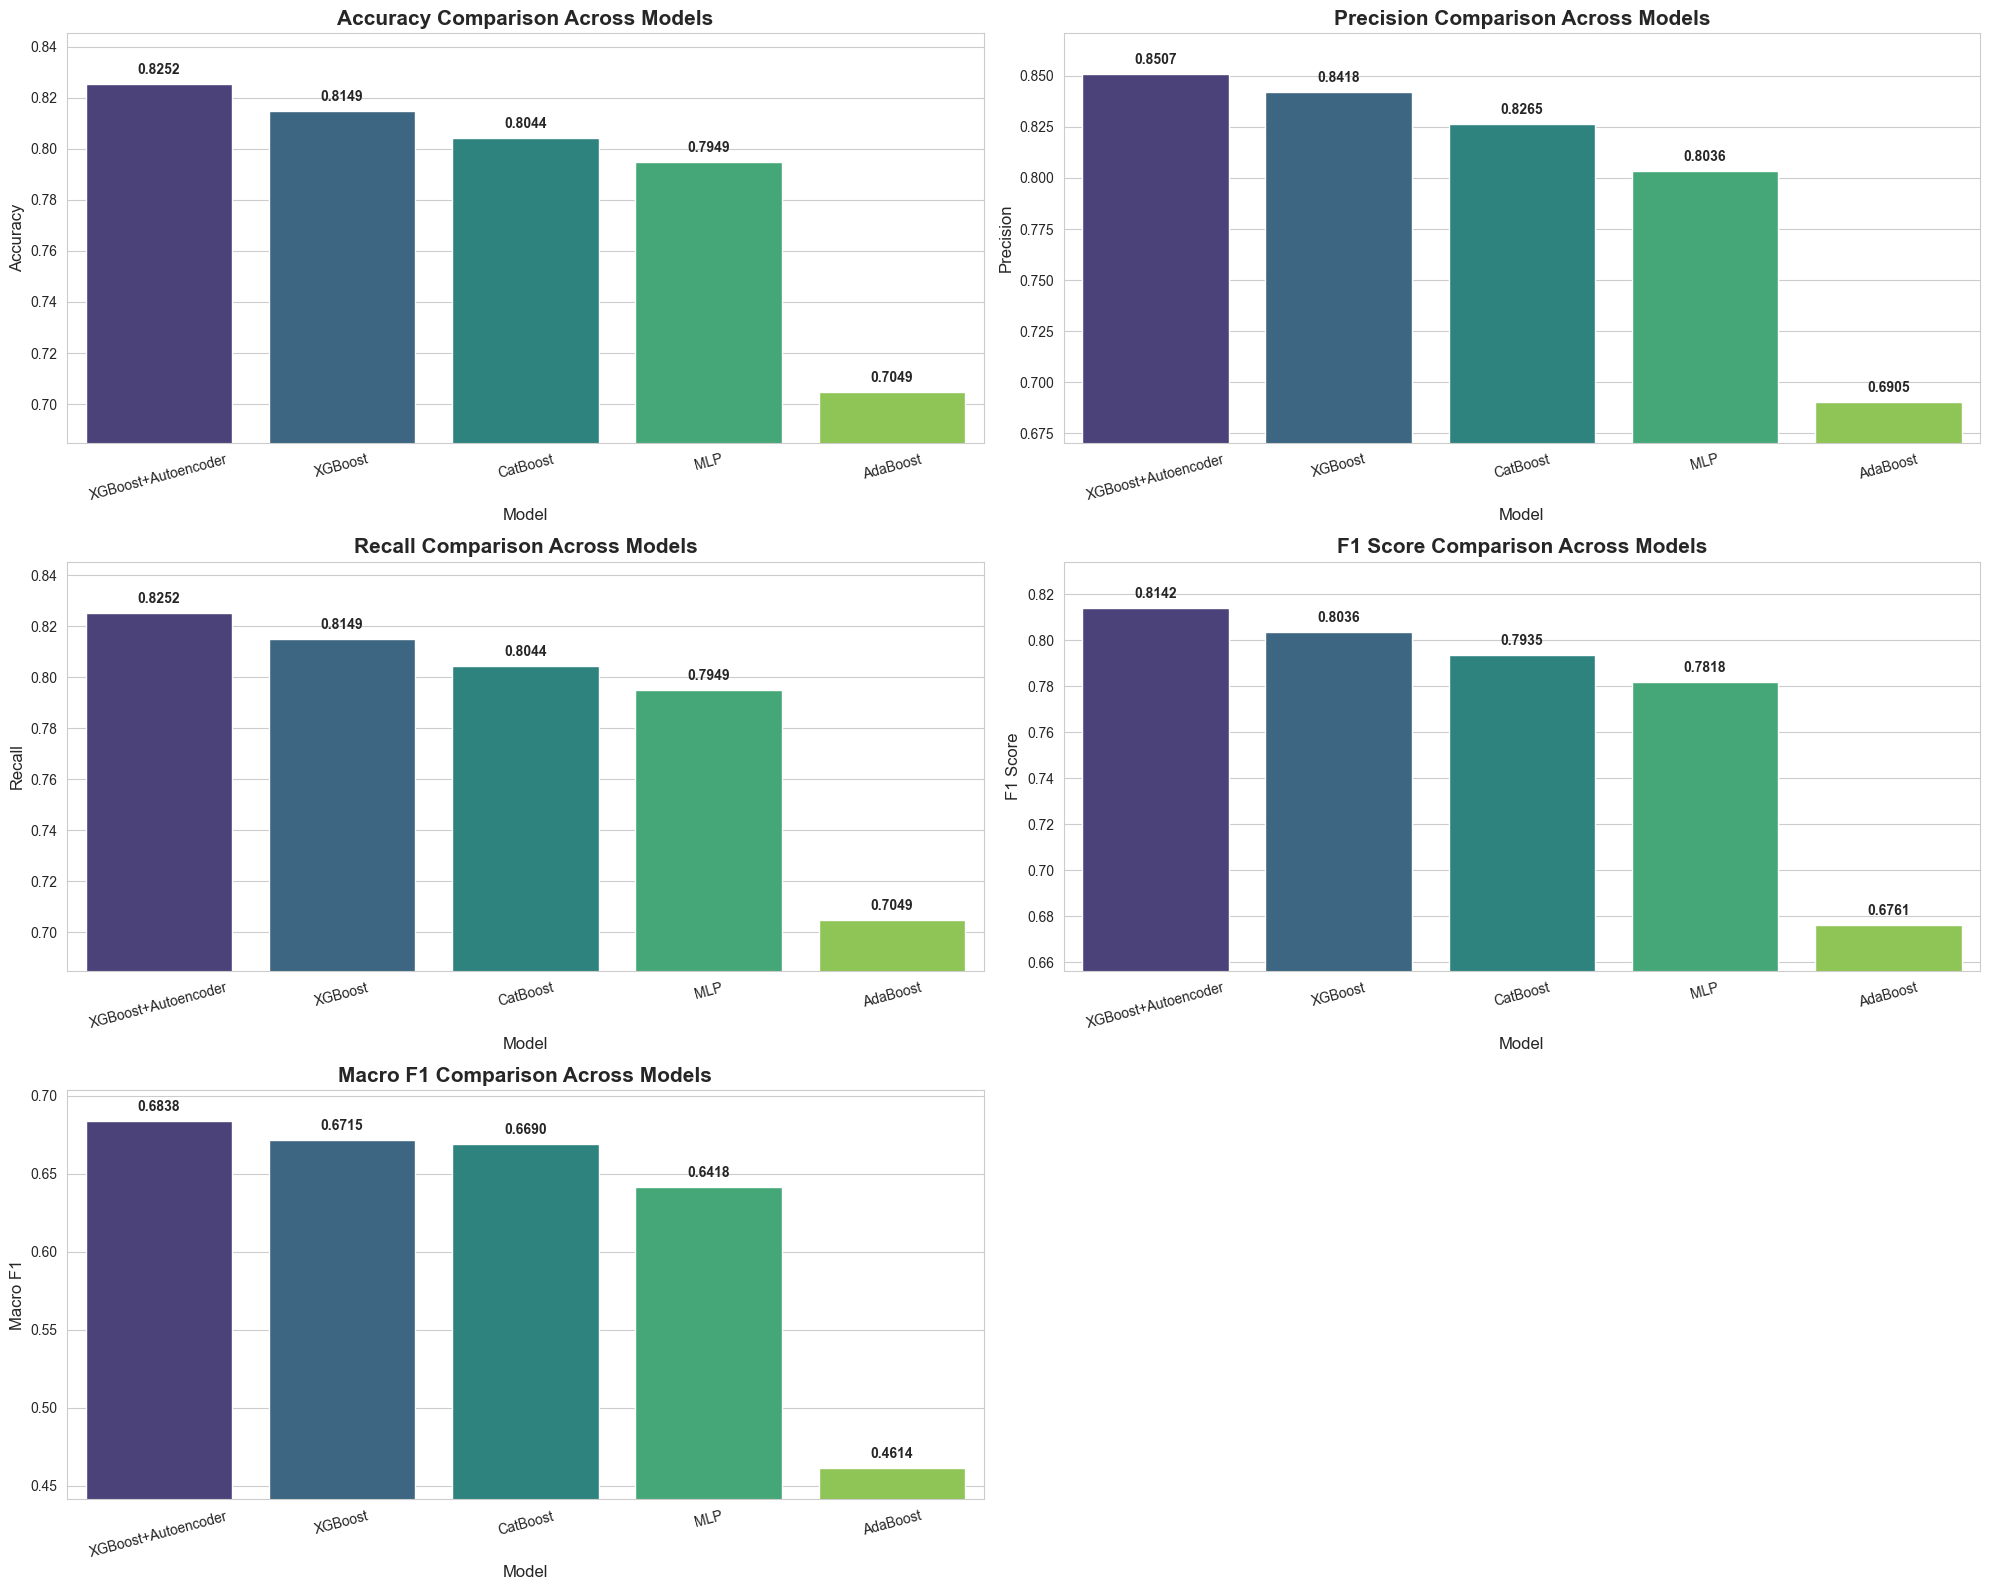

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics_to_plot = [

    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'Macro F1'
]


sns.set_style("whitegrid")


fig, axes = plt.subplots(

    nrows=3,
    ncols=2,

    figsize=(20, 16)
)

axes = axes.flatten()


for i, metric in enumerate(metrics_to_plot):

    plot_data = all_metrics.dropna(
        subset=[metric]
    )

    plot_data = plot_data.sort_values(
        by=metric,
        ascending=False
    )

    # -----------------------------------------------------
    # BARPLOT
    # -----------------------------------------------------

    ax = sns.barplot(

        x='model_name',

        y=metric,

        data=plot_data,

        ax=axes[i],

        palette='viridis'
    )


    axes[i].set_title(

        f'{metric} Comparison Across Models',

        fontsize=15,
        fontweight='bold'
    )

    axes[i].set_xlabel(
        'Model',
        fontsize=12
    )

    axes[i].set_ylabel(
        metric,
        fontsize=12
    )

    axes[i].tick_params(
        axis='x',
        rotation=15
    )

    # -----------------------------------------------------
    # DYNAMIC Y LIMIT
    # -----------------------------------------------------

    min_val = plot_data[metric].min()
    max_val = plot_data[metric].max()

    margin = 0.02

    axes[i].set_ylim(
        max(0, min_val - margin),
        min(1.0, max_val + margin)
    )

    for p in ax.patches:

        height = p.get_height()

        ax.annotate(

            f'{height:.4f}',

            (
                p.get_x() + p.get_width() / 2.,
                height
            ),

            ha='center',
            va='bottom',

            fontsize=10,
            fontweight='bold',

            xytext=(0, 5),

            textcoords='offset points'
        )

fig.delaxes(axes[-1])
plt.tight_layout()

plt.show()

plt.close()

In [64]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [65]:
import shap

explainer = shap.TreeExplainer(
    xgb_model
)

In [67]:
original_feature_names = list(X_train.columns)

latent_feature_names = [
    f"latent_{i}"
    for i in range(X_train_encoded.shape[1])
]

all_feature_names = (
    original_feature_names +
    latent_feature_names
)

In [68]:
sample_data = X_test_fused[:1000]

In [69]:
shap_values = explainer.shap_values(
    sample_data
)

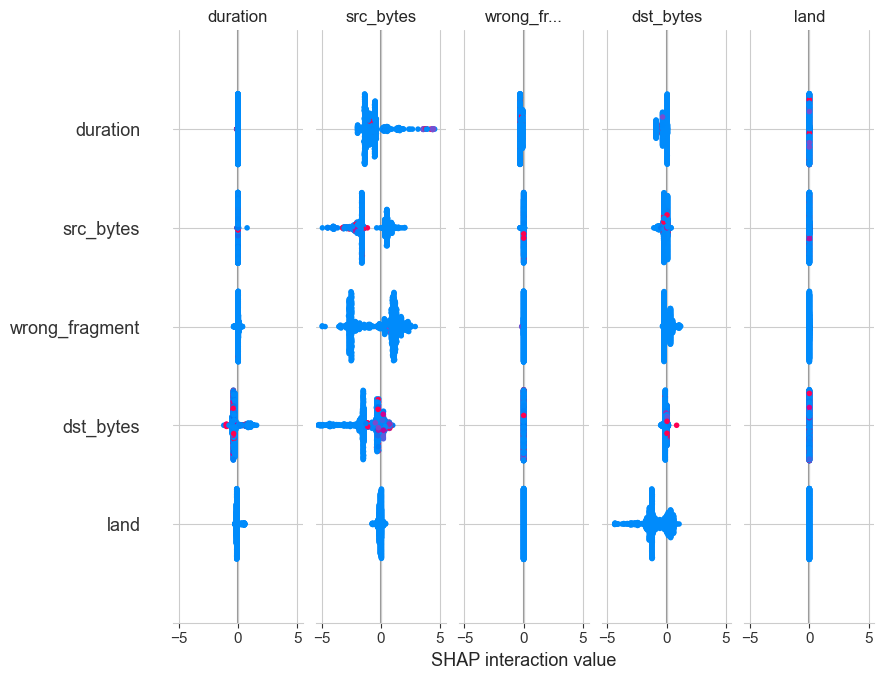

In [70]:
shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=all_feature_names
)